**Compare the electron counts for a flat spectrum point source between ScopeSim and the ETC.**

In [1]:
import scopesim as sim
from scopesim.source.source_templates import uniform_illumination
from scopesim.source.source import Source
sim.link_irdb("../..")

import numpy as np
from astropy.wcs import WCS
from astropy import units as u
import matplotlib.pyplot as plt
from synphot import SourceSpectrum, Observation
from synphot.units import PHOTLAM
from synphot.models import ConstFlux1D

import sys
sys.path.append("../../../../uvex-mission/uvex-mission")
import uvex
from uvex.sensitivity import config, filters, spectrometer

config.dump_defaults() 
UVEX = config.UVEX(default=True)

The collecting area is slightly different in the ETC than it is in ScopeSim, where it is calculated from the size of the largest mirror in the optical train (the first one). For an apples-to-apples comparison we'll manually set the ScopeSim telescope area.

All detector effects are turned off, and the SpacecraftPointing effect is set at the same FWHM as in the ETC slit throughput calculation.

In [ ]:
# Set up
etc_area = np.pi * (0.75*u.m*0.5)**2
pixel_scale = 0.8 * u.arcsec
bin_width = 1e-04 * u.um

cmdlss = sim.UserCommands(use_instrument="UVEX", set_modes=['lss'])

cmdlss["!SIM.spectral.spectral_bin_width"] = bin_width.value
cmdlss["!SIM.spectral.spectral_resolution"] = 5000
cmdlss["!SIM.computing.oversampling_x"] = 10
cmdlss["!SIM.computing.oversampling_y"] = 10
cmdlss["!SIM.computing.crop_y"] = [-20., 20.]
cmdlss["!TEL.area"] = etc_area  # m^2

optlss = sim.OpticalTrain(cmdlss)
om = optlss.optics_manager

# Set oversampling
om['oversample_image'].meta['include'] = True
om['downsample_image'].meta['include'] = True

# Turn off the new PSF effects
om['slit_psf'].meta['include'] = False
om['detector_psf'].meta['include'] = False

# And turn off detector effects for now
om['lss_dark_current'].meta['include'] = False
om['lss_shot_noise'].meta['include'] = False
om['lss_readout_noise'].meta['include'] = False
om['lss_ad_conversion'].meta['include'] = False # keep in electrons

# Same as assumed in ETC
om['spacecraft_pointing'].meta['fwhm'] = 2.25
om['spacecraft_pointing'].meta['include'] = True

# The detector gain was also changed in the config to be 1.0
# ...can we set this from a notebook?

z_levels = np.arange(0, 1000, 100)
for z in z_levels:
    effs = om.get_z_order_effects(int(z))
    print(f"\nz-range {z}..{z+99}")
    for eff in effs:
        el = next(oe for oe in om.optical_elements if eff in oe.effects)
        print(f"{el.meta['name']:<20} | {eff.display_name:<20} | {eff.__class__.__name__:<20} | z_order={eff.z_order}")


py.warnings - WARNING: /Users/eshread/Desktop/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:169: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

astar.scopesim.utils - ERROR: File cannot be found: tbd_det_linearity.dat
astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits

z-range 0..99
UVEX                 | ota_surface_list     | SurfaceList          | z_order=(20, 120, 520)
LSS                  | relay_optics         | SurfaceList          | z_order=(20, 120, 520)
LSS                  | surfaces             | SurfaceList          | z_order=(20, 120, 520)
LSS                  | slit_geometry        | UVEXSlitMask         | z_order=(27, 227, 627)
LSS                  | spectral_traces      | SpectralTraceList    | z_order=(70, 270, 670)
uvex_lss_detector    | LSS_Detector         | DetectorList         | z_order=(90, 290, 390, 490)

z-range 100..199
UVEX                 |

Input a star with AB mag 25.5 at the center of the slit, with a constant flux spectrum.

In [3]:
src_mag = 25.5 * u.ABmag
model_spec = SourceSpectrum(ConstFlux1D, amplitude=src_mag)
constant_source = Source(x=[12600.], y=[0.], spectra = model_spec, weight=[1.0], ref=[0])

py.warnings - WARNING: /Users/eshread/Desktop/UVEX/uvex-mission/ScopeSim/scopesim/effects/spectral_trace_list.py:211: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



 FOV effects:   0%|          | 0/6 [00:00<?, ?it/s]

 SpacecraftPointing effect convolution: 100%|██████████| 2339/2339 [00:11<00:00, 207.57it/s]


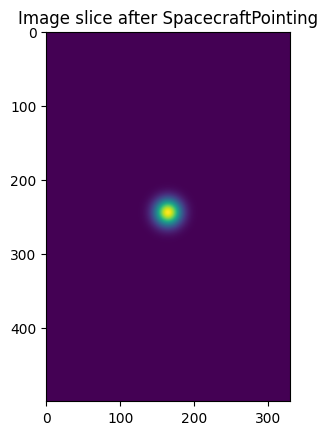

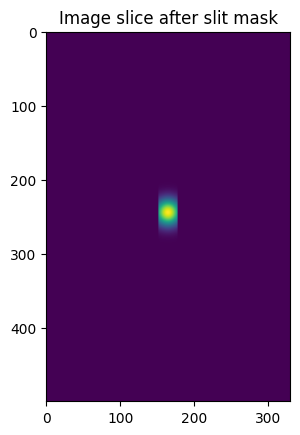

astar.scopesim.effects.apertures - Calculated slit throughput: 0.7100621685752608
astar.scopesim.effects.spectral_trace_list_utils - Loaded dispersion from file: /Users/eshread/Desktop/UVEX/uvex-mission/irdb/UVEX/data_files/UVIM_LSS_dispersion.dat
astar.scopesim.effects.spectral_trace_list_utils - WARNING: map_spectra_to_focal_plane: 42347 negative pixels


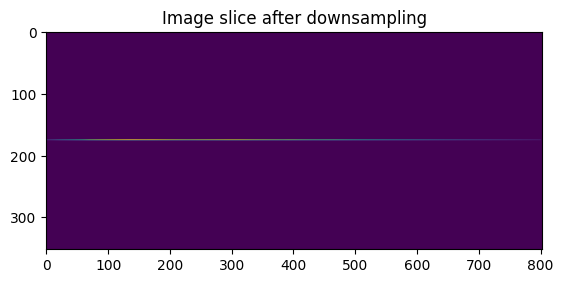

astar.scopesim.optics.image_plane - WARNING: No BUNIT found in added HDU.
astar.scopesim.detector.detector_manager - Extracting from 2 detectors...


In [4]:
# Run the simulation
optlss.observe(constant_source, update=True)
hdulist_lss = optlss.readout()[0]

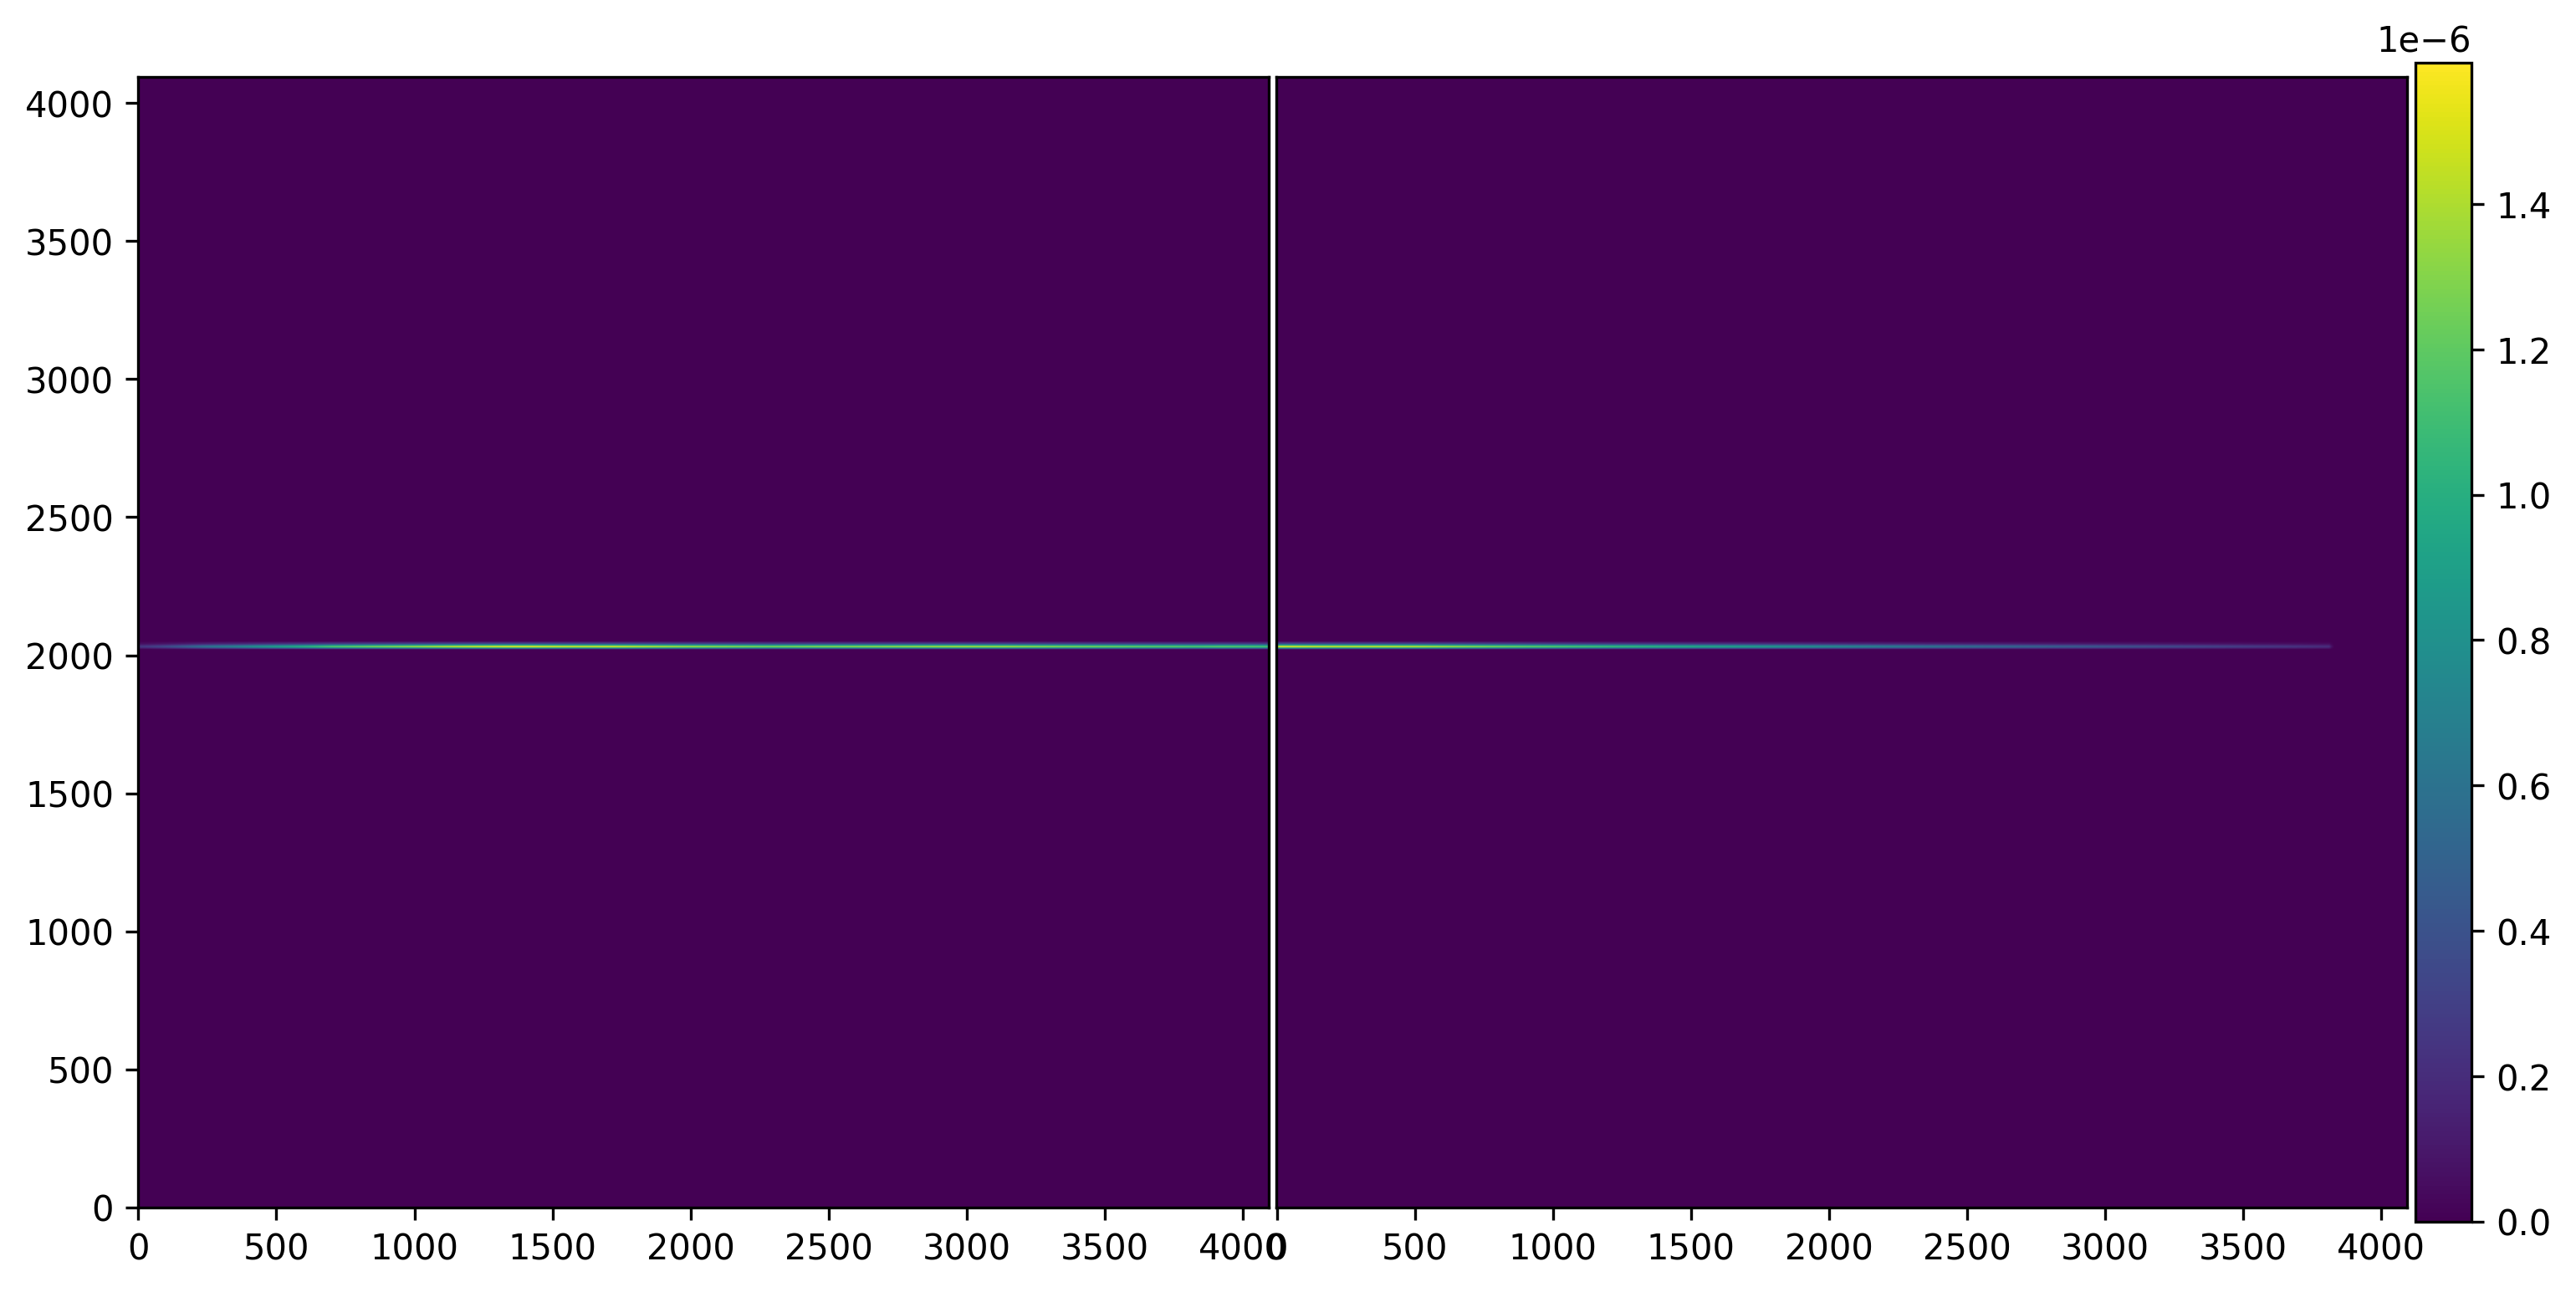

In [5]:
# Plot the output image
fig, axs = plt.subplots(ncols=3, figsize=(12, 6), gridspec_kw={'width_ratios': [1, 1, 0.05]}, dpi=300)
ax0, ax1, cax = axs
ax0.tick_params(axis="both", labelsize=10)
ax1.tick_params(axis="x", labelsize=10)
ax1.set_yticks([])

im0 = ax0.imshow(hdulist_lss[1].data, origin='lower')
im1 = ax1.imshow(hdulist_lss[2].data, origin='lower')

cbar = fig.colorbar(im1, cax=cax)
plt.subplots_adjust(wspace=0.01)
plt.show()

In [6]:
# Now rectify the spectra (get back into wavelengths/slit positions)
tracelist = optlss["spectral_traces"]
rectified = tracelist.rectify_traces(hdulist_lss, xi_min=-1800., xi_max=1800., bin_width=bin_width.value)

astar.scopesim.effects.spectral_trace_list - Full wavelength range: 0.12 .. 0.35 um


 Traces:   0%|          | 0/1 [00:00<?, ?it/s]

astar.scopesim.effects.spectral_trace_list_utils - Rectifying UVIM_LSS_trace (0.12 .. 0.35 um)


Ratio of raw and rectified image electron counts (should be 1): 1.00


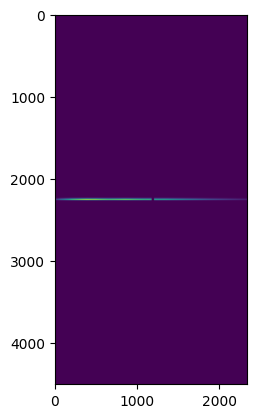

In [7]:
# Verify flux is conserved during rectification
raw_flux = (float(hdulist_lss[1].data.sum()) + float(hdulist_lss[2].data.sum())) * hdulist_lss[1].header['CDELT1D'] * hdulist_lss[1].header['CDELT2D'] # multiply by pixel area to get result in electrons
rectified_flux = rectified[1].data.sum() * bin_width.value * pixel_scale.value
print(f"Ratio of raw and rectified image electron counts (should be 1): {rectified_flux / raw_flux:.2f}")

plt.imshow(rectified[1].data)
plt.show()

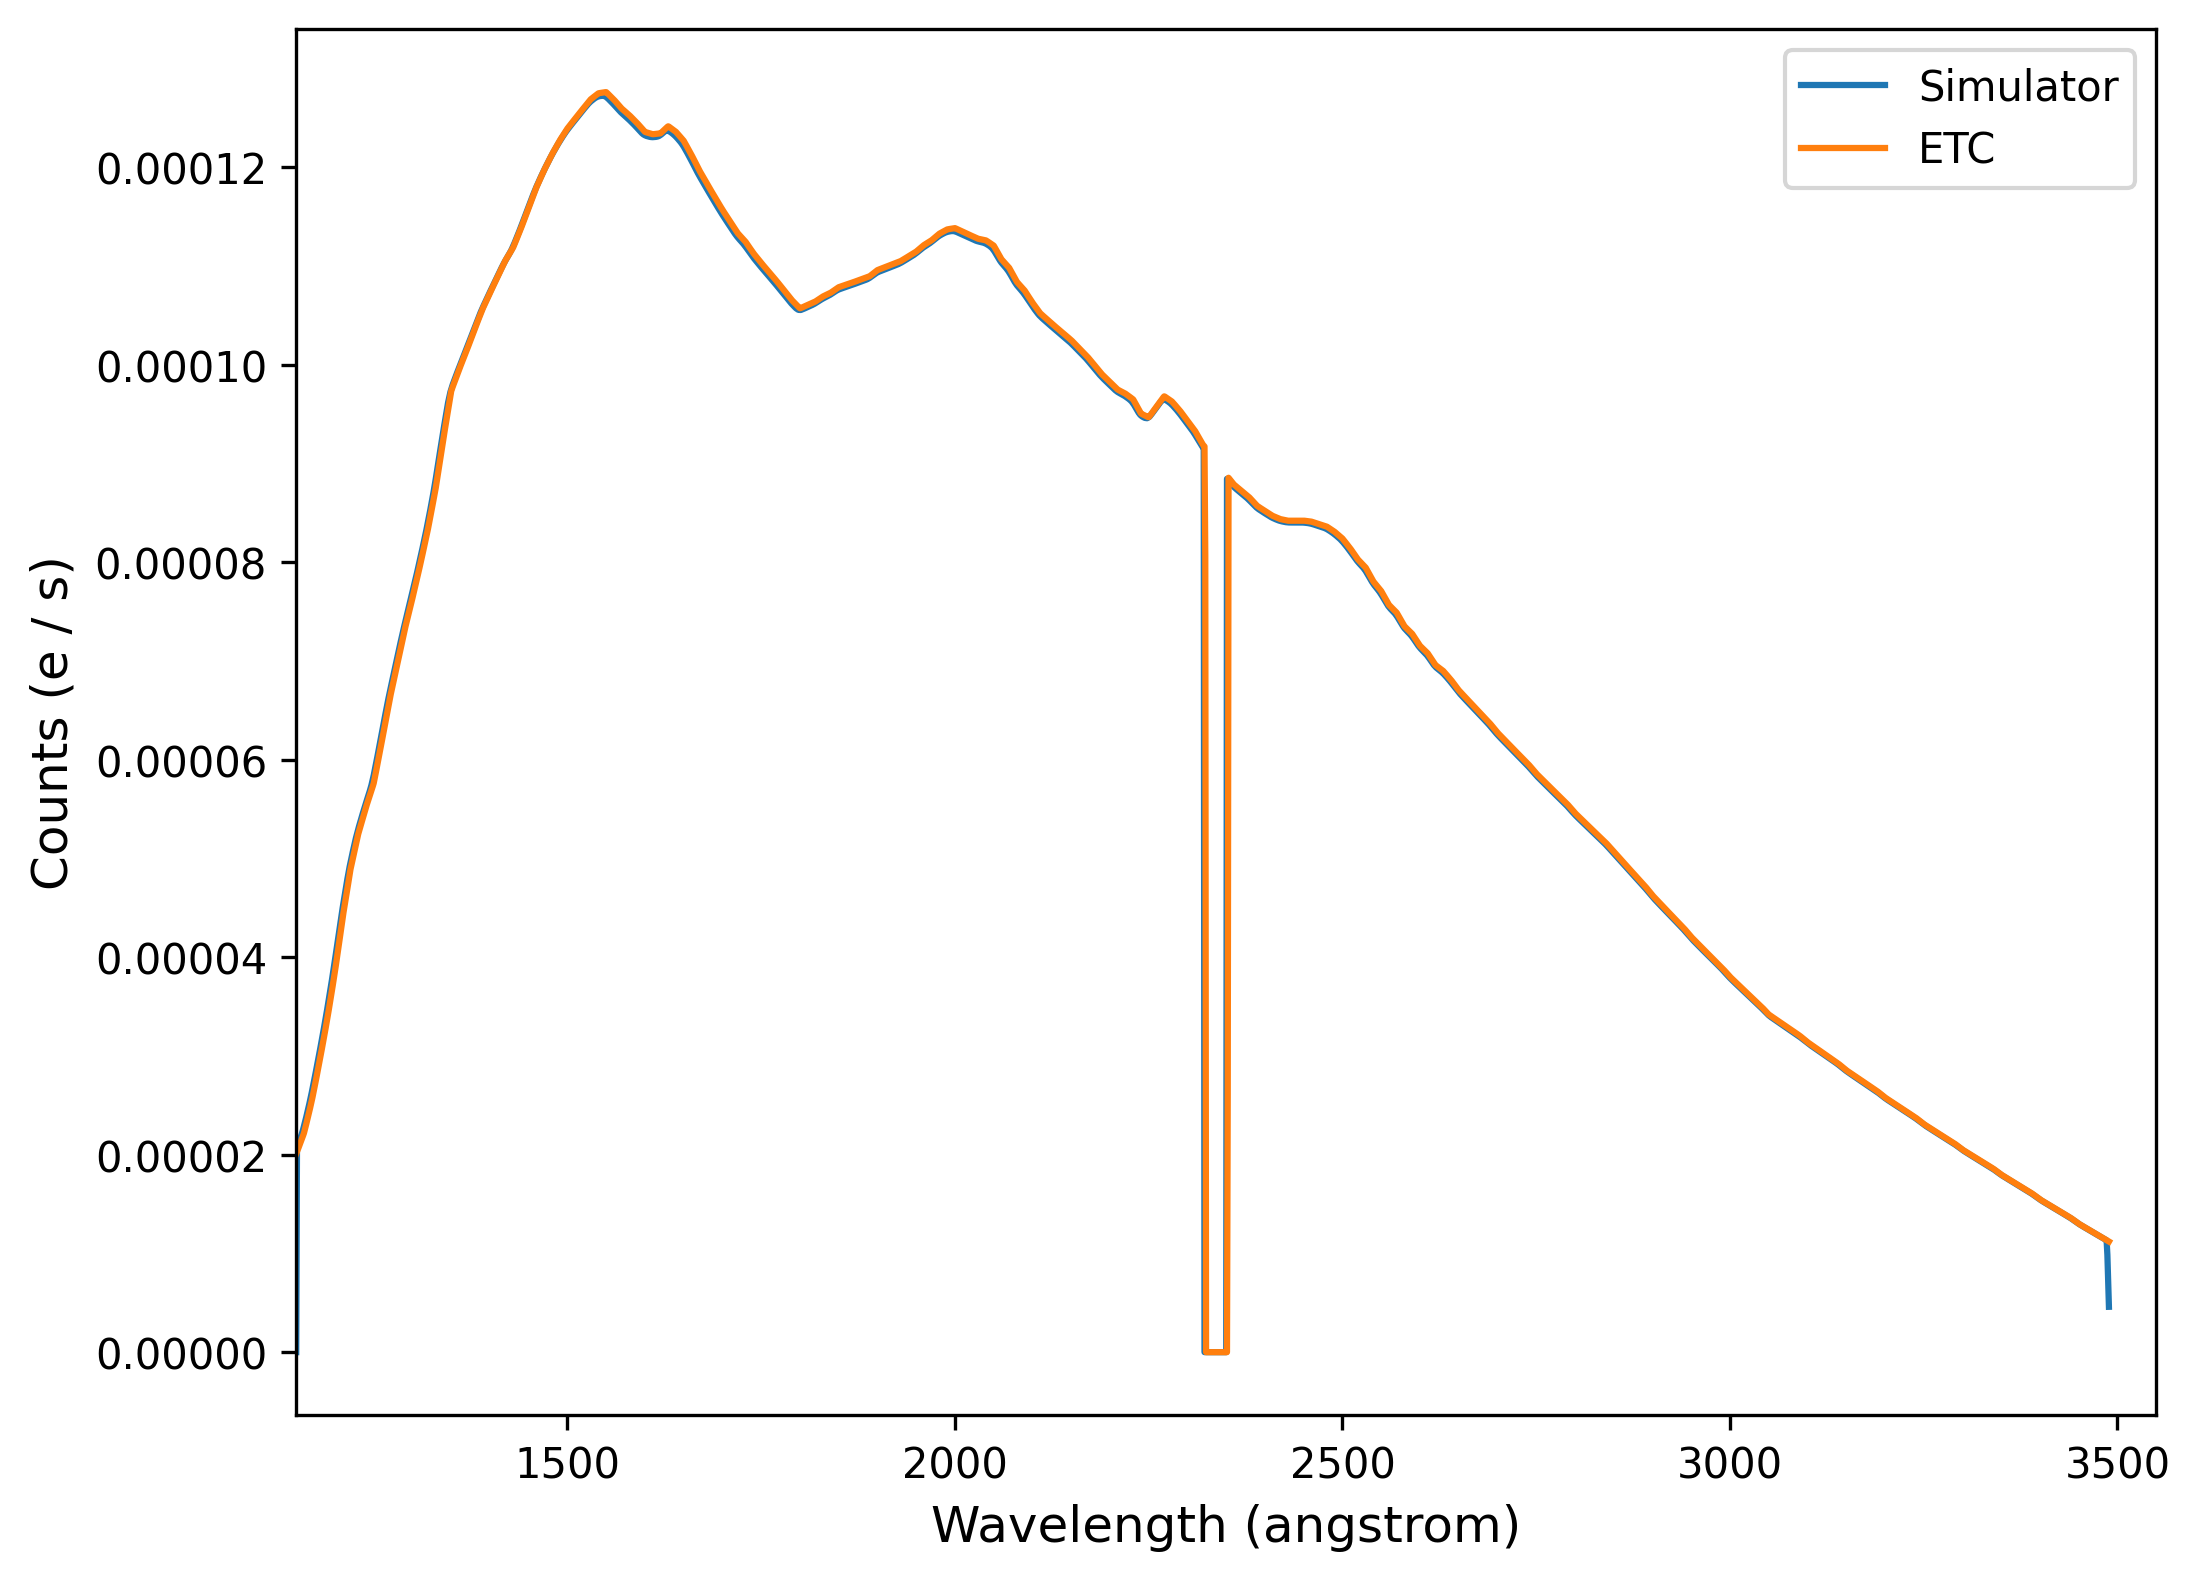

In [8]:
exptime = optlss.cmds["!OBS.dit"] * optlss.cmds["!OBS.ndit"] * u.s

w = WCS(rectified[1].header)
n_lam = rectified[1].data.shape[1]
n_xi = rectified[1].data.shape[0]
pix_x = np.arange(n_lam) 
pix_y = np.zeros(n_lam) 
lam_world = w.all_pix2world(np.column_stack([pix_x, pix_y]), 0)
lam = lam_world[:, 0] * (u.m).to(u.AA)

nonzero_xi, nonzero_lam = np.where(rectified[1].data > 0.) 
nonzero_xi, nonzero_lam = np.unique(nonzero_xi), np.unique(nonzero_lam)

lss_band = filters.spec_bandpass()
spec_bins = spectrometer.load_spectral_bins()

lss_obs = Observation(model_spec, lss_band, binset=lam)
obs_spec = lss_obs.sample_binned(flux_unit='count', area=UVEX.AREA).value * u.electron / u.s

# Sum along the slit axis. This appears to already be divided out by the exposure time in sec...
trace1 = rectified[1].data[:, :].sum(axis=0)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(lam, np.array(trace1), label="Simulator")
ax.plot(lam, obs_spec, label='ETC')
ax.set_xlabel("Wavelength (angstrom)", fontsize=12)
ax.set_ylabel("Counts (e / s)", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.xlim(1150, 3550)
plt.show()


Plot the differences between the ScopeSim and ETC spectra.

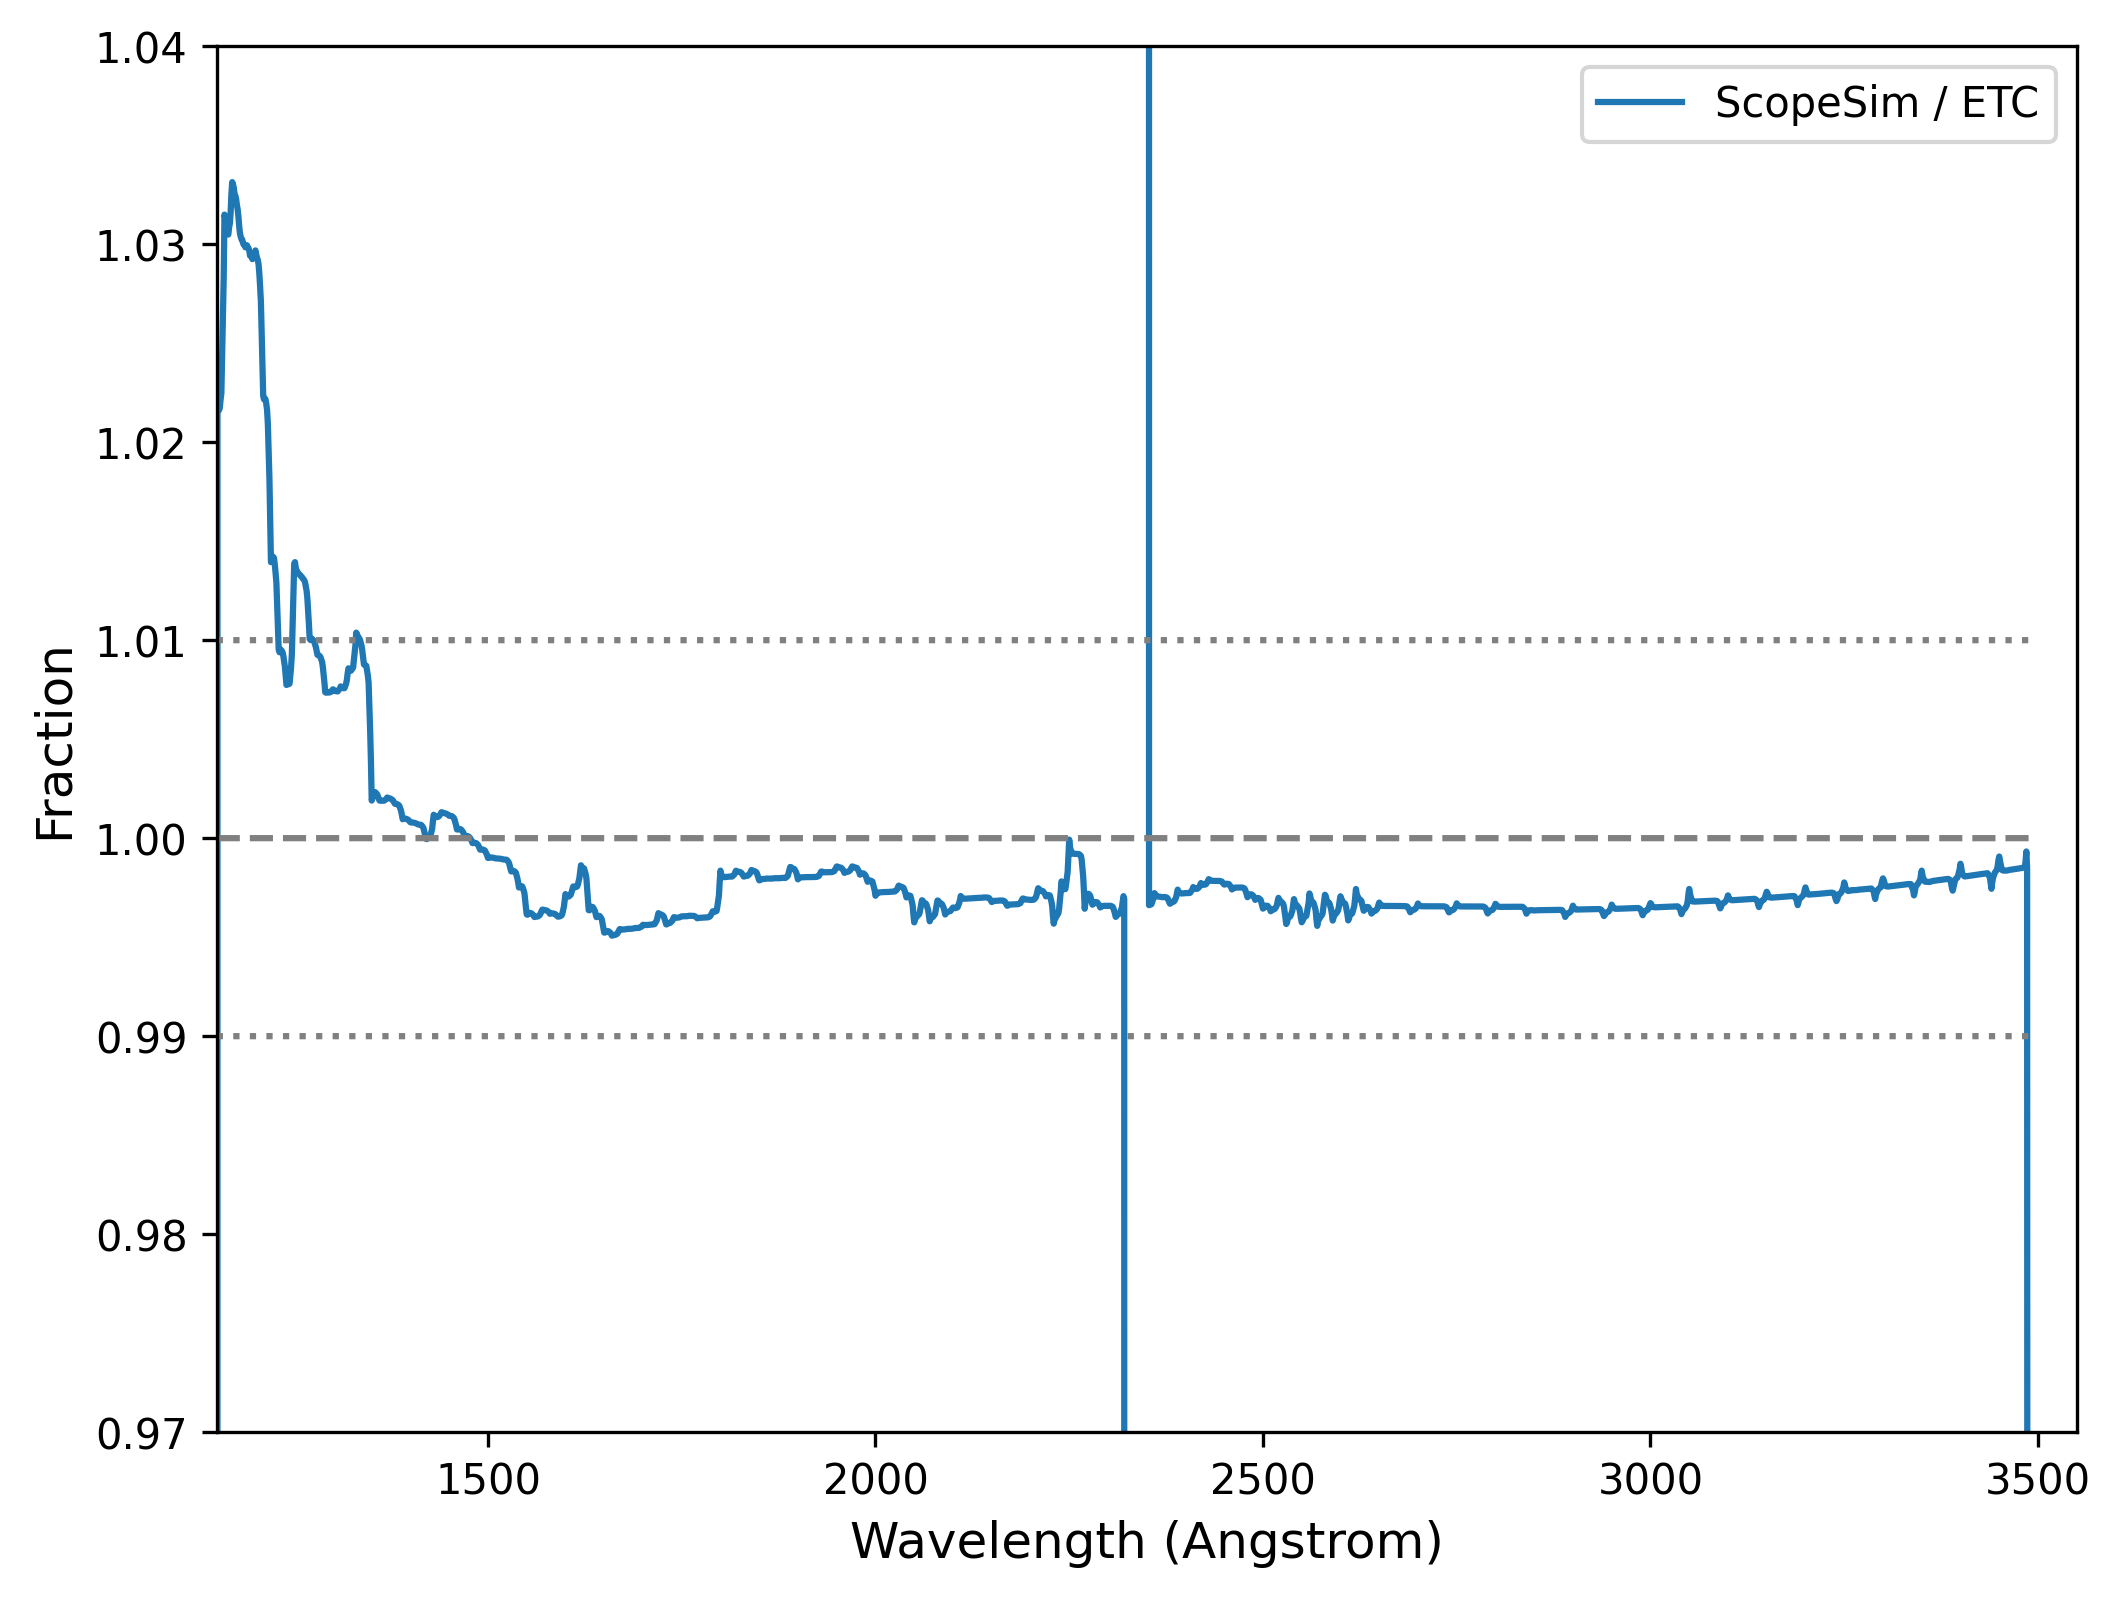

In [10]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
ax.plot(lam, (np.array(trace1)/np.array(obs_spec)), label="ScopeSim / ETC")
ax.plot(lam, np.ones_like(lam), linestyle='--', color='grey')
ax.plot(lam, np.array([0.99]*len(lam)), linestyle=':', color='grey')
ax.plot(lam, np.array([1.01]*len(lam)), linestyle=':', color='grey')
ax.set_xlabel("Wavelength (Angstrom)", fontsize=12)
ax.set_ylabel("Fraction", fontsize=12)
plt.legend(loc="upper right", fontsize=10)
plt.xlim(1150, 3550)
plt.ylim(0.97, 1.04)
plt.show()